# 02 — Temporal split → calibration → the money layer

The argument of this notebook, in order:

1. Split by **time**, with an embargo, because a random split would be indefensible.
2. Train, then **calibrate** — because everything after this multiplies a probability by rupees.
3. Report the metric panel **honestly**, against the base rate.
4. Put money on it: price every error, then solve for the threshold **per action**.

Each step exists because the next one would be meaningless without it.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from returnrisk.config import load_config
from returnrisk.plots import use_house_style

use_house_style()
cfg = load_config(Path.cwd().parent / "config.yaml")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
print("config loaded | seed:", cfg["seed"], "| data source:", cfg["data"]["source"])

config loaded | seed: 42 | data source: uci


In [2]:
from returnrisk.data.loader import load_transactions
from returnrisk.data.labeling import build_labelled_orders
from returnrisk.features import build_feature_frame

txn = load_transactions(cfg)
orders, report = build_labelled_orders(txn, cfg)
feat = build_feature_frame(orders)
lines = txn[~txn["is_cancellation"]]
print(f"{len(feat):,} orders | base rate {feat['returned'].mean():.2%}")

30,047 orders | base rate 18.53%


## 1. Temporal split with an embargo

Fix the **deployment moment** at the first day of the test window. At that instant the merchant
can only hold labels for orders placed at least 90 days earlier — nothing newer has a closed
return window. So the fitting window (train *and* calibration, fitted at the same moment) stops
90 days short, and the orders in that gap are dropped.

Training right up to the boundary quietly teaches the model on labels that would not exist yet.

In [3]:
from returnrisk.split import temporal_split

sp = temporal_split(feat, cfg)
print(sp.describe())

Temporal split (no shuffling, embargoed):
  train  n= 15,694  2009-12-01 -> 2010-11-01  base rate=19.00%
  calib  n=  3,923  2010-11-01 -> 2010-12-23  base rate=17.44%
  test   n=  7,511  2011-03-24 -> 2011-09-09  base rate=17.57%
  embargo=90d before the deployment moment 2011-03-24 (dropped 2,919 orders whose return window was still open)


In [4]:
fig, ax = plt.subplots(figsize=(10, 2.6))
for name, part, color in [("train", sp.train, "#2a78d6"),
                          ("calib", sp.calib, "#eb6834"),
                          ("test", sp.test, "#1baf7a")]:
    ax.barh(0, (part["order_date"].max() - part["order_date"].min()).days,
            left=part["order_date"].min(), height=0.45, color=color, label=f"{name} (n={len(part):,})")
gap_start = pd.Timestamp(sp.meta["fitting_window_end"])
gap_end = pd.Timestamp(sp.meta["deployment_moment"])
ax.barh(0, (gap_end - gap_start).days, left=gap_start, height=0.45,
        color="#d03b3b", alpha=0.35, label=f"embargo ({sp.meta['embargo_days']}d)")
ax.set_yticks([]); ax.legend(loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.15))
ax.set_title("Temporal split: the embargo is the gap the model never sees")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

## 2. Fit the train-only artefacts, then train

Two things are fitted on the **training slice alone**: reference prices for the discount proxy,
and the category return rate (which is additionally **out-of-fold** within train, so no training
row sees its own label through the encoder).

In [5]:
from returnrisk.features import FeatureBuilder, FEATURE_COLUMNS

builder = FeatureBuilder(cfg).fit(sp.train, lines)
train = builder.transform(sp.train, lines, is_train=True)
calib = builder.transform(sp.calib, lines)
test = builder.transform(sp.test, lines)

print(f"{len(FEATURE_COLUMNS)} features, all knowable at checkout:")
for i, c in enumerate(FEATURE_COLUMNS, 1):
    print(f"  {i:>2}. {c}")

28 features, all knowable at checkout:
   1. order_value_gbp
   2. log_order_value
   3. n_lines
   4. total_quantity
   5. avg_qty_per_line
   6. avg_unit_price
   7. max_unit_price
   8. min_unit_price
   9. price_spread
  10. basket_concentration
  11. discount_pct
  12. hour
  13. day_of_week
  14. is_weekend
  15. month
  16. days_to_christmas
  17. prior_orders
  18. is_new_customer
  19. days_since_last_order
  20. customer_tenure_days
  21. prior_avg_order_value
  22. prior_return_rate
  23. prior_returns_observed
  24. category_return_rate
  25. category_order_count
  26. country
  27. region
  28. top_category


In [6]:
from returnrisk.model import train_and_calibrate

model, brier = train_and_calibrate(train, calib, builder, cfg)
proba = model.predict_proba(test)
proba_raw = model.predict_proba_raw(test)
y = test["returned"].to_numpy()

print(f"Brier on the calibration slice:")
print(f"  raw LightGBM        {brier['brier_uncalibrated_calib_slice']:.5f}")
print(f"  after isotonic      {brier['brier_calibrated_calib_slice']:.5f}   <- calibration helps")

Brier on the calibration slice:
  raw LightGBM        0.13216
  after isotonic      0.12876   <- calibration helps


## 3. Calibration — and why it is load-bearing

A score of 0.30 has to **mean** "30 of every 100 such orders come back", because the money layer
multiplies it by a rupee cost. Raw boosted-tree scores do not have that property.

Note there is **no SMOTE and no class weighting** anywhere. They shift the predicted base rate
away from the true one, which is exactly the property being relied on here.

In [7]:
from returnrisk.metrics import calibration_frame, expected_calibration_error

cal_raw = calibration_frame(y, proba_raw)
cal_cal = calibration_frame(y, proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
for ax, frame, name, ece in [(axes[0], cal_raw, "Raw LightGBM", expected_calibration_error(y, proba_raw)),
                             (axes[1], cal_cal, "After isotonic", expected_calibration_error(y, proba))]:
    ax.plot([0, 0.7], [0, 0.7], color="#898781", linestyle="--")
    ax.plot(frame["mean_predicted"], frame["observed_rate"], "o-", color="#2a78d6", markersize=6)
    ax.set_title(f"{name}  (ECE {ece:.4f})")
    ax.set_xlabel("Mean predicted")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Observed return rate")
plt.show()
cal_cal.round(4)

,bin,n,mean_predicted,observed_rate,lower_edge,upper_edge,gap
0,0,499,0.0491,0.0601,0.0000,0.0574,0.0110
1,1,1704,0.0574,0.0775,0.0574,0.0957,0.0200
2,2,429,0.0957,0.0816,0.0957,0.1168,-0.0141
3,3,1095,0.1208,0.1142,0.1168,0.1429,-0.0066
4,4,614,0.1498,0.1564,0.1429,0.1931,0.0065
5,5,634,0.1979,0.2129,0.1931,0.2196,0.0151
6,6,1659,0.2360,0.2417,0.2196,0.3149,0.0057
7,7,877,0.4146,0.4173,0.3149,1.0000,0.0027


## 4. The honest metric panel

**AUC-PR is the headline**, always printed next to the base rate. On a 17.6% positive rate a
model can post 82% accuracy by predicting "no return" for everything.

In [8]:
from returnrisk.metrics import evaluate, lift_table
from returnrisk.money import CostModel

cost = CostModel(cfg)
value_inr = cost.to_inr(test["order_value_gbp"])
t_star, bd, sweep = cost.optimal_threshold(y, proba, value_inr, cost.default_action)

panel = evaluate(y, proba, t_star)
print(panel.summary())
print()
print(f"  base rate (the AUC-PR floor)   {panel.base_rate:.4f}")
print(f"  AUC-PR                         {panel.auc_pr:.4f}   = {panel.auc_pr_lift_vs_base:.2f}x base")
print(f"  ROC-AUC (secondary)            {panel.roc_auc:.4f}")
print(f"  accuracy                       {panel.accuracy:.4f}   <- always-predict-no scores "
      f"{1 - panel.base_rate:.4f}, and is worth Rs.0")

AUC-PR 0.3409 (base rate 17.57%, lift 1.94x) | ROC-AUC 0.7046 | Brier 0.1318 | @t=0.122: P 0.252 R 0.787 F1 0.382 (flagged 4,116 / 7,511)

  base rate (the AUC-PR floor)   0.1757
  AUC-PR                         0.3409   = 1.94x base
  ROC-AUC (secondary)            0.7046
  accuracy                       0.5529   <- always-predict-no scores 0.8243, and is worth Rs.0


In [9]:
lift = lift_table(y, proba)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(lift)), lift["return_rate"], color="#2a78d6", width=0.65)
ax.axhline(panel.base_rate, color="#898781", linestyle="--")
ax.set_xticks(range(len(lift))); ax.set_xticklabels([f"D{i+1}" for i in range(len(lift))])
ax.set_xlabel("Risk decile (D1 = riskiest)"); ax.set_ylabel("Observed return rate")
ax.set_title("Does the ranking work?")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
lift[["decile", "n", "returns", "return_rate", "lift"]].round(3)

,decile,n,returns,return_rate,lift
0,0,752,327,0.435,2.474
1,1,751,196,0.261,1.485
2,2,751,180,0.240,1.364
3,3,751,159,0.212,1.205
4,4,751,130,0.173,0.985
5,5,751,99,0.132,0.750
6,6,751,65,0.087,0.492
7,7,751,54,0.072,0.409
8,8,751,64,0.085,0.485
9,9,751,46,0.061,0.349


## 5. The money layer

Per order, with `V` = order value and `M` = margin:

```
FN_cost(V) = reverse logistics + restocking%·V + margin reversed by the refund

flagged & returned      (TP) : ops + (1 - effectiveness)·FN_cost(V)
flagged & not returned  (FP) : ops + conversion_loss_prob·M     <- the false-positive cost
not flagged & returned  (FN) : FN_cost(V)
not flagged & not ret.  (TN) : 0
```

`effectiveness < 1` is deliberate: an intervention is not a cure. Crediting a flag with the full
return cost would inflate savings by 2–4×.

In [10]:
from returnrisk.money import format_inr

print(f"Cost model (all figures in {cost.symbol}):")
print(f"  GBP -> INR                  {cost.gbp_to_inr}")
print(f"  gross margin                {cost.margin_pct:.0%}")
print(f"  reverse logistics / order   {format_inr(cost.reverse_logistics)}")
print(f"  restocking                  {cost.restocking_pct:.0%} of order value")
print()
example = np.array([500.0 * cost.gbp_to_inr])
print(f"A GBP500 order -> {format_inr(example[0])}; missing its return costs "
      f"{format_inr(cost.fn_cost(example)[0])}")
print()
for key, a in cost.actions.items():
    print(f"  {key:<18} ops {format_inr(a.ops_cost_inr):>8} | churn risk "
          f"{a.conversion_loss_prob:>5.0%} | prevents {a.effectiveness:>4.0%} of returns")

Cost model (all figures in Rs.):
  GBP -> INR                  105.0
  gross margin                28%
  reverse logistics / order   Rs.250
  restocking                  4% of order value

A GBP500 order -> Rs.52.5 K; missing its return costs Rs.17.1 K

  manual_pack_check  ops    Rs.40 | churn risk    0% | prevents  25% of returns
  remove_discount    ops     Rs.5 | churn risk    8% | prevents  45% of returns
  remove_cod         ops     Rs.5 | churn risk   18% | prevents  65% of returns


In [11]:
fig, ax = plt.subplots(figsize=(9, 4.6))
for (key, color) in zip(cost.actions, ["#2a78d6", "#eb6834", "#1baf7a"]):
    t, b, sw = cost.optimal_threshold(y, proba, value_inr, key)
    ax.plot(sw["threshold"], sw["total_cost"] / 1e5, color=color, label=key)
    ax.scatter([t], [b.total_cost / 1e5], s=60, color=color, zorder=5, edgecolor="white", linewidth=2)
    ax.annotate(f"t*={t:.3f}", xy=(t, b.total_cost / 1e5), xytext=(8, 10),
                textcoords="offset points", color=color, fontsize=9)
ax.axhline(bd.do_nothing_cost / 1e5, color="#898781", linestyle="--")
ax.annotate("do nothing", xy=(0.95, bd.do_nothing_cost / 1e5), xytext=(0, 5),
            textcoords="offset points", ha="right", color="#898781", fontsize=9)
ax.set_xlabel("Threshold"); ax.set_ylabel(f"Total expected cost ({cost.symbol} lakh)")
ax.set_title("Each intervention has its own cost-minimising threshold")
ax.set_xlim(0, 1); ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### 5.1 Per-action thresholds — the differentiator

Expect **monotone** behaviour: costlier mistakes buy a higher bar and fewer flags.

In [12]:
action_table = cost.optimal_threshold_per_action(y, proba, value_inr)
view = action_table[["action", "fp_cost_mean_inr", "t_star", "orders_flagged",
                     "flag_rate", "precision", "recall", "savings_inr"]].copy()
view["fp_cost_mean_inr"] = view["fp_cost_mean_inr"].map(lambda v: format_inr(v, cost.symbol))
view["savings_inr"] = view["savings_inr"].map(lambda v: format_inr(v, cost.symbol))
print(view.to_string(index=False))
print()
print("monotone (cheaper action -> lower t* -> more flags):",
      action_table["t_star"].is_monotonic_increasing
      and action_table["orders_flagged"].is_monotonic_decreasing)

           action fp_cost_mean_inr   t_star  orders_flagged  flag_rate  precision   recall savings_inr
manual_pack_check            Rs.40 0.056497            7403   0.985621   0.178036 0.998485  Rs.68.94 L
  remove_discount         Rs.1.1 K 0.121855            4116   0.547996   0.252430 0.787121  Rs.76.57 L
       remove_cod         Rs.2.4 K 0.197339            2764   0.367994   0.295948 0.619697  Rs.84.95 L

monotone (cheaper action -> lower t* -> more flags): True


In [13]:
# The closed form explains the monotonicity: t* = (ops + l*M) / (e*FN + l*M)
unit = 500.0 * cost.gbp_to_inr
print(f"Closed-form break-even for a GBP500 order:")
for key in cost.actions:
    print(f"  {key:<18} analytic t* = {cost.analytic_threshold(unit, key):.4f}")

Closed-form break-even for a GBP500 order:
  manual_pack_check  analytic t* = 0.0094
  remove_discount    analytic t* = 0.1335
  remove_cod         analytic t* = 0.1931


### 5.2 The rupee confusion matrix

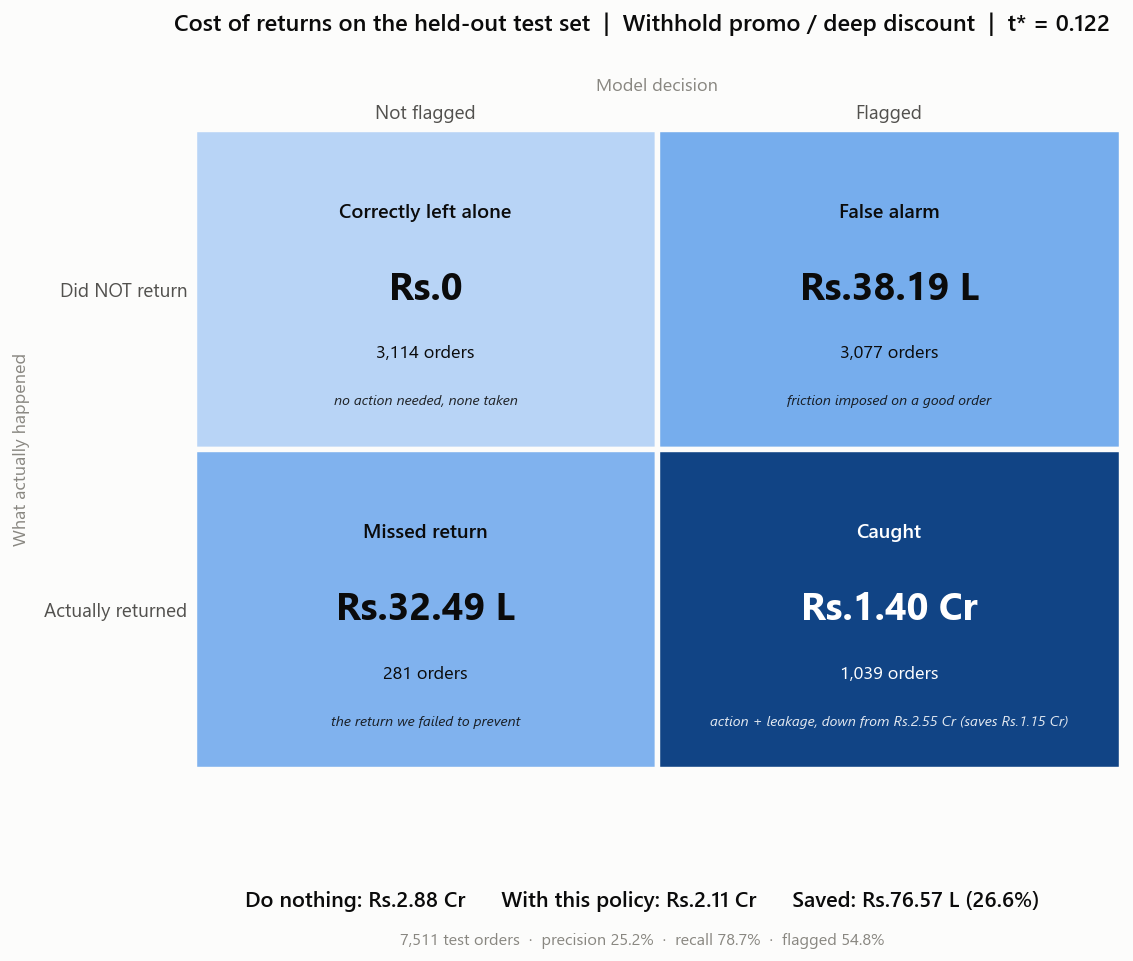

do nothing     Rs.2.88 Cr
this policy    Rs.2.11 Cr
SAVED          Rs.76.57 L  (26.6%)


In [14]:
from returnrisk.plots import money_confusion_matrix
from IPython.display import Image, display
from pathlib import Path

out = Path.cwd().parent / "reports" / "nb_money_confusion_matrix.png"
money_confusion_matrix(bd, out, action_label=cost.actions[cost.default_action].label,
                       symbol=cost.symbol)
display(Image(filename=str(out)))

print(f"do nothing   {format_inr(bd.do_nothing_cost, cost.symbol):>12}")
print(f"this policy  {format_inr(bd.total_cost, cost.symbol):>12}")
print(f"SAVED        {format_inr(bd.savings, cost.symbol):>12}  ({bd.savings/bd.do_nothing_cost:.1%})")

### 5.3 Against real baselines

The rules must be ones a merchant would actually write.

In [15]:
from returnrisk.baselines import compare_baselines, rule_diagnostics

print("Do the rules fire on anything real?")
for r in rule_diagnostics(test, cfg):
    print(f"  {r['rule'][:52]:<54} fires {r['orders_flagged']:>5,} ({r['flag_rate']:>5.1%})  "
          f"precision {r['precision']:.3f}  lift {r['lift_vs_base']:.2f}x")
print()

base_table = compare_baselines(test, proba, cost, cfg, t_star)
show = base_table[["policy", "orders_flagged", "precision", "recall", "total_cost_inr",
                   "savings_vs_do_nothing_inr"]].copy()
show["total_cost_inr"] = show["total_cost_inr"].map(lambda v: format_inr(v, cost.symbol))
show["savings_vs_do_nothing_inr"] = show["savings_vs_do_nothing_inr"].map(
    lambda v: format_inr(v, cost.symbol))
print(show.to_string(index=False))

Do the rules fire on anything real?
  Deep discount: flag orders >= 30% off the reference    fires   523 ( 7.0%)  precision 0.191  lift 1.09x
  Big ticket: flag orders worth GBP 500 or more          fires 1,617 (21.5%)  precision 0.260  lift 1.48x
  Repeat returner: flag customers with >= 1 confirmed    fires 4,626 (61.6%)  precision 0.218  lift 1.24x

                                                                 policy  orders_flagged  precision   recall total_cost_inr savings_vs_do_nothing_inr
                                                Do nothing (status quo)               0   0.000000 0.000000     Rs.2.88 Cr                      Rs.0
      Rule -- Deep discount: flag orders >= 30% off the reference price             523   0.191205 0.075758     Rs.2.87 Cr                 Rs.47.9 K
                  Rule -- Big ticket: flag orders worth GBP 500 or more            1617   0.259740 0.318182     Rs.2.31 Cr                Rs.56.15 L
Rule -- Repeat returner: flag customers with >= 1

### 5.4 Is the recommendation robust to being wrong about costs?

Every rupee above rests on two guesses. Sweep both.

In [16]:
from returnrisk.sensitivity import cost_sensitivity, sensitivity_summary

grid = cost_sensitivity(test, proba, cost, cfg)
s = sensitivity_summary(grid)
print(f"profitable in {s['n_cells_profitable']}/{s['n_cells']} cost scenarios")
print(f"t* ranges {s['t_star_min']:.3f} - {s['t_star_max']:.3f} (median {s['t_star_median']:.3f})")
print(f"savings range {s['savings_pct_min']:.1%} - {s['savings_pct_max']:.1%} of the return bill")
print(f"worst corner: {s['worst_cell']}")
grid.pivot(index="fn_multiplier", columns="fp_multiplier", values="t_star").round(3)

profitable in 36/36 cost scenarios
t* ranges 0.056 - 0.630 (median 0.160)
savings range 0.9% - 43.3% of the return bill
worst corner: {'fn_multiplier': 0.5, 'fp_multiplier': 8.0}


fp_multiplier,0.25,0.50,1.00,2.00,4.00,8.00
fn_multiplier,,,,,,
0.50,0.057,0.122,0.206,0.310,0.630,0.63
0.75,0.056,0.117,0.197,0.310,0.390,0.63
1.00,0.056,0.057,0.122,0.206,0.310,0.63
1.50,0.056,0.056,0.117,0.197,0.310,0.39
2.00,0.056,0.056,0.057,0.122,0.206,0.31
3.00,0.056,0.056,0.056,0.117,0.197,0.31


## 6. What the model is weakest at

An average hides the segment where the ranking has collapsed. Lift over each segment's **own**
base rate is the fair comparison across differing prevalences.

In [17]:
from returnrisk.segments import segment_metrics, weakness_sentence, fairness_table, disparity_sentence

seg = segment_metrics(test, proba, cost, t_star)
print(weakness_sentence(seg))
print()
print(seg[seg["reliable"]][["dimension", "segment", "n_orders", "base_rate",
                            "auc_pr", "auc_pr_lift", "precision"]].round(3).to_string(index=False))

Weakest reliable segment: customer_type=new (n=601, base rate 14.81%, AUC-PR 0.219 = 1.48x base, precision 0.192 vs portfolio-wide behaviour).

    dimension   segment  n_orders  base_rate  auc_pr  auc_pr_lift  precision
  basket_size      6-15      2259      0.159   0.301        1.892      0.215
  basket_size     16-30      2170      0.212   0.361        1.702      0.265
  basket_size       1-5      1706      0.087   0.139        1.597      0.162
  basket_size       30+      1376      0.256   0.441        1.724      0.316
     category     OTHER      1618      0.176   0.356        2.019      0.278
     category       224       660      0.200   0.367        1.837      0.252
     category       226       382      0.160   0.291        1.820      0.216
     category       227       351      0.197   0.358        1.819      0.277
     category       221       307      0.205   0.316        1.540      0.246
     category       475       295      0.207   0.479        2.315      0.300
customer_

In [18]:
fair = fairness_table(test, proba, t_star)
print(disparity_sentence(fair))
print()
print(fair[fair["reliable"]][["dimension", "segment", "n_orders", "base_rate", "flag_rate",
                              "over_flagging_ratio", "precision"]].round(3).to_string(index=False))

Largest precision disparity is on order_value: <150 is flagged at 19.2% but converts to only 15.4% precision, versus 36.3% for 1k+ -- a 20.8% gap, meaning <150 customers absorb more friction per prevented return.

    dimension   segment  n_orders  base_rate  flag_rate  over_flagging_ratio  precision
       region        UK      6777      0.175      0.529                3.016      0.257
       region        EU       696      0.182      0.723                3.961      0.223
customer_type returning      6910      0.178      0.542                3.043      0.258
customer_type       new       601      0.148      0.616                4.157      0.192
  order_value    500-1k      1143      0.244      0.734                3.007      0.299
  order_value   150-300      1838      0.145      0.510                3.513      0.201
  order_value   300-500      2205      0.221      0.739                3.347      0.255
  order_value      <150      1853      0.079      0.192                2.438      

## 7. The thing that will actually break this: selective labels

Acting on a score censors the outcome. Simulated below — and mitigated with an always-approve
holdout.

In [19]:
from returnrisk.selective_labels import run_experiment, verdict

sl = run_experiment(test, proba, cost, cfg, t_star)
print(verdict(sl))
print()
print(sl.comparison[["model", "auc_pr_period2", "precision_period2", "recall_period2",
                     "mean_score_period2"]].round(4).to_string(index=False))
print()
print(f"cost of the {sl.holdout_frac:.0%} always-approve holdout: "
      f"{format_inr(sl.holdout_cost_inr, cost.symbol)}")

Acting on 2,159 of 3,755 period-1 orders censors 2,048 labels. The observed base rate collapses from 17.74% to 3.94%, and a model retrained on that data scores AUC-PR 0.150 on clean period-2 data versus 0.338 for the incumbent. With a 5% always-approve holdout and inverse-propensity weighting the reconstructed base rate is 17.21% and the retrained model recovers to 0.255.

                                 model  auc_pr_period2  precision_period2  recall_period2  mean_score_period2
                 original (no retrain)          0.3381             0.2524          0.7554              0.1648
          retrained on censored labels          0.1502             0.1217          0.0214              0.0264
retrained w/ 5% always-approve holdout          0.2550             0.2421          0.4358              0.1394

cost of the 5% always-approve holdout: Rs.3.55 L


## Where this leaves us

| | |
|---|---|
| AUC-PR | **0.341** vs a 0.176 base rate = **1.94×** |
| Calibrated | Brier improves; ECE ~0.01 |
| Money | ₹2.88 Cr → ₹2.11 Cr, **₹76.6 L saved** |
| Per action | monotone thresholds, 0.056 / 0.122 / 0.197 |
| Robustness | profitable in 36/36 cost scenarios |
| Weakest at | **new customers** (1.48× vs 1.94× overall) |
| Biggest risk | **selective labels** — mitigated, priced, and documented |

`python run_demo.py` regenerates all of this plus the full report set in `reports/`.